In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import time
from google.colab import files

Mounted at /content/drive


In [ ]:
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

if zip_name.endswith(".zip"):
    with zipfile.ZipFile(zip_name, "r") as zip_ref:
        zip_ref.extractall("/content/zappos_data")
    data_dir = Path("/content/zappos_data")
    print(f" Extracted dataset to: {data_dir}")
else:
    data_dir = Path("/content")
    print(f" Using uploaded directory: {data_dir}")

Saving ut-zap50k-images.zip to ut-zap50k-images.zip
 Extracted dataset to: /content/zappos_data


In [ ]:
data_dir = Path("/content/zappos_data/ut-zap50k-images")  # or your extraction folder

filepaths = list(data_dir.rglob("*.jpg"))
print(f" Found {len(filepaths):,} .jpg images.")

Labels = [os.path.split(os.path.split(p)[0])[1] for p in filepaths]
img_df = pd.DataFrame({"FilePaths": [str(p) for p in filepaths], "Labels": Labels})

# Extract subfolder pattern like "Boots - Timberland"
fp = img_df["FilePaths"].str.split(pat="/", n=8, expand=True)
Label1 = fp[5] + " - " + fp[6]
Label1 = Label1.rename("Label1")
img_df2 = pd.concat([img_df, Label1], axis=1)
img_df2 = img_df2.drop("Labels", axis=1)

 Found 50,025 .jpg images.


In [ ]:
# Group into 4 main categories

# Extract true top-level footwear category (Boots / Sandals / Shoes / Slippers)
img_df2["Category"] = img_df2["FilePaths"].apply(lambda x: Path(x).parts[-4].lower())

# Normalize any variations
img_df2["Category"] = img_df2["Category"].replace({
    "boots": "boots",
    "sandals": "sandals",
    "shoes": "shoes",
    "slippers": "slippers"
})

print(img_df2["Category"].value_counts())

Category
shoes       30169
boots       12832
sandals      5741
slippers     1283
Name: count, dtype: int64


In [ ]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
print(f" Random seed set to {SEED}")

train_df, val_df = train_test_split(
    img_df2,
    test_size=0.25,
    stratify=img_df2["Category"],
    random_state=SEED
)

print(f"\n Train size: {len(train_df)}, Validation size: {len(val_df)}")

 Random seed set to 42

 Train size: 37518, Validation size: 12507


In [ ]:
# Create ImageDataGenerators

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="FilePaths",
    y_col="Category",
    target_size=(28, 28),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=64,
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="FilePaths",
    y_col="Category",
    target_size=(28, 28),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=64
)

num_classes = len(train_gen.class_indices)
print(f"\n Detected {num_classes} categories:", list(train_gen.class_indices.keys()))

Found 37518 validated image filenames belonging to 4 classes.
Found 12507 validated image filenames belonging to 4 classes.

 Detected 4 categories: ['boots', 'sandals', 'shoes', 'slippers']


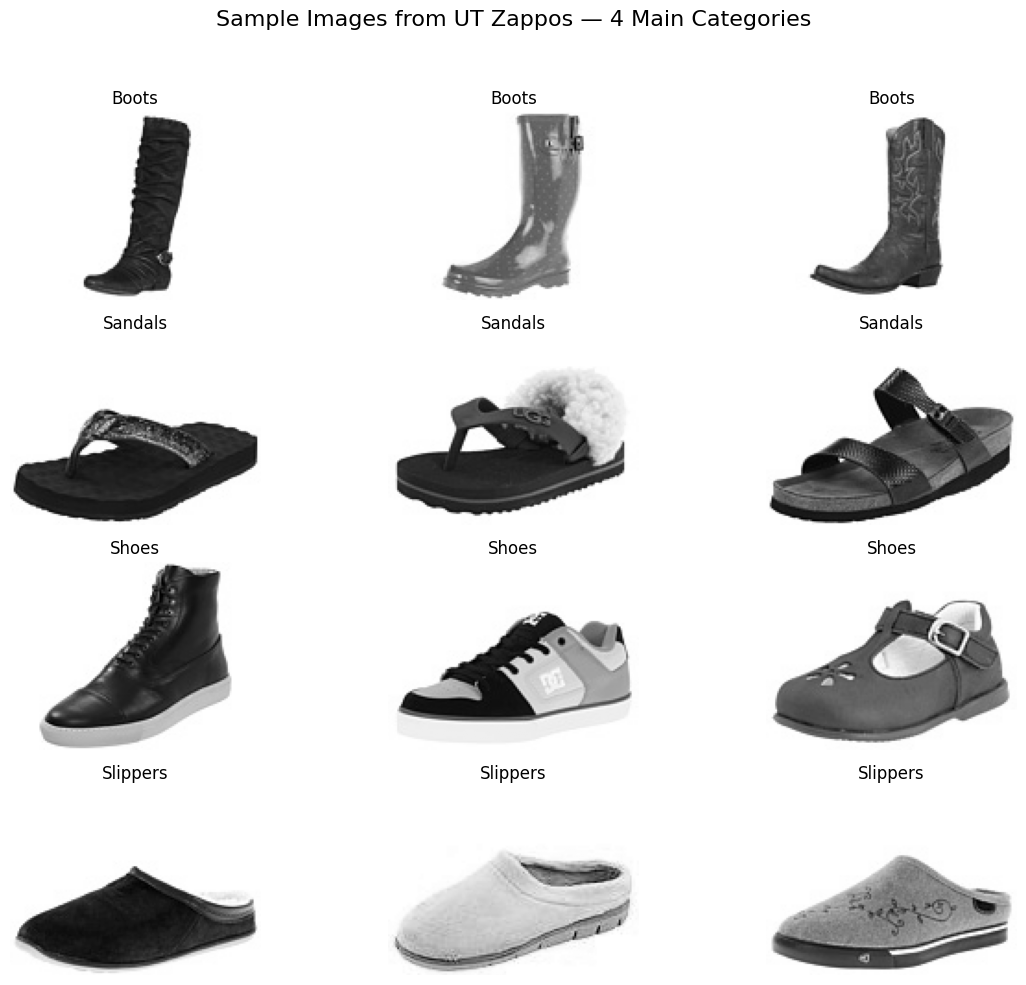

In [ ]:
import random
from PIL import Image

# The 4 footwear categories you created
main_categories = ["boots", "sandals", "shoes", "slippers"]

plt.figure(figsize=(12, 10))

row = 0
col = 0
index = 1

for cat in main_categories:
    cat_df = img_df2[img_df2["Category"] == cat]

    if len(cat_df) == 0:
        print(f"⚠️ No images found for category: {cat}")
        continue

    # sample up to 3 images per category
    sample_size = min(3, len(cat_df))
    sample_rows = cat_df.sample(sample_size, random_state=42).reset_index(drop=True)

    for i in range(sample_size):
        img_path = sample_rows.loc[i, "FilePaths"]
        label = sample_rows.loc[i, "Category"]

        try:
            img = Image.open(img_path).convert("L")
            plt.subplot(4, 3, index)
            plt.imshow(img, cmap='gray')
            plt.title(label.capitalize())
            plt.axis("off")
            index += 1
        except Exception as e:
            print(f"⚠️ Could not load image {img_path}: {e}")

plt.suptitle("Sample Images from UT Zappos — 4 Main Categories", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
def build_zappos_subnet(num_classes):
    inputs = keras.Input(shape=(28,28,1))
    x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128,3,activation='relu',padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128,activation='relu',name='dense128')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes,activation='softmax')(x)
    return keras.Model(inputs,outputs,name="Zappos_FMNIST_Subnet")

model = build_zappos_subnet(num_classes)
model.summary()

Model: "Zappos_FMNIST_Subnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense128 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,700 (428.52 KB)

 Trainable params: 109,700 (428.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
weight_paths = {
    "FMNIST_base": "/content/drive/MyDrive/MSDS458/fmnist_footwear_subnet.weights.h5",
    "Deep_CNN": "/content/drive/MyDrive/MSDS458/Deep_CNN_best_subnet.weights.h5",
    "From_Scratch": None
}

histories, results = {}, {}

for name, path in weight_paths.items():
    print(f"\n Training model initialized from {name} ...")

    # Build fresh model every time
    model = build_zappos_subnet(num_classes)
    model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Load weights ONLY if path is given
    if path is not None:
        try:
            model.load_weights(path)
            print(f" Loaded pretrained weights: {path}")
        except Exception as e:
            print(f" Could not load weights for {name}: {e}")
    else:
        print(" Training from scratch (no pretrained weights).")

    # Train model
    start = time.time()
    history = model.fit(train_gen, validation_data=val_gen, epochs=10, verbose=2)
    duration = (time.time() - start) / 60
    val_loss, val_acc = model.evaluate(val_gen, verbose=0)

    results[name] = (val_acc, duration)
    histories[name] = history

    print(f" {name}: Val Accuracy={val_acc:.4f} | Time={duration:.2f} min")

    # Save models
    model.save(f"/content/{name}_zappos_finetuned.keras")
    model.save_weights(f"/content/{name}_zappos_finetuned.weights.h5")


 Training model initialized from FMNIST_base ...
 Could not load weights for FMNIST_base: A total of 1 objects could not be loaded. Example error message for object <Dense name=dense_1, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(128, 4), Received: value.shape=(128, 3). Target variable: <Variable path=dense_1/kernel, shape=(128, 4), dtype=float32, value=[[-0.21013749 -0.15571974  0.08314252 -0.09843578]
 [ 0.20190156 -0.01810239  0.03857118  0.06474337]
 [ 0.07062516  0.14520386  0.14492309 -0.1446096 ]
 [-0.19733569  0.09476516 -0.13306242 -0.1279415 ]
 [ 0.07574925 -0.15661721 -0.17526157 -0.17210272]
 [ 0.10934347 -0.17655897  0.1390548  -0.12231161]
 [-0.05769838 -0.08270349 -0.17161551  0.07098642]
 [-0.09184416  0.10854679 -0.09964444 -0.0295831 ]
 [ 0.0274211  -0.13491505 -0.07512371  0.19391274]
 [-0.0920297   0.1339778   0.2122261   0.17222726]
 [ 0.08223188 -0.05957486  0.07546803 -0

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


587/587 - 33s - 56ms/step - accuracy: 0.6915 - loss: 0.8290 - val_accuracy: 0.7768 - val_loss: 0.6292
Epoch 2/10
587/587 - 22s - 38ms/step - accuracy: 0.7827 - loss: 0.6153 - val_accuracy: 0.7974 - val_loss: 0.5403
Epoch 3/10
587/587 - 23s - 39ms/step - accuracy: 0.8052 - loss: 0.5457 - val_accuracy: 0.8275 - val_loss: 0.4816
Epoch 4/10
587/587 - 23s - 40ms/step - accuracy: 0.8268 - loss: 0.4922 - val_accuracy: 0.8474 - val_loss: 0.4469
Epoch 5/10
587/587 - 23s - 39ms/step - accuracy: 0.8380 - loss: 0.4615 - val_accuracy: 0.8463 - val_loss: 0.4271
Epoch 6/10
587/587 - 22s - 37ms/step - accuracy: 0.8476 - loss: 0.4403 - val_accuracy: 0.8604 - val_loss: 0.4070
Epoch 7/10
587/587 - 23s - 39ms/step - accuracy: 0.8545 - loss: 0.4219 - val_accuracy: 0.8617 - val_loss: 0.3966
Epoch 8/10
587/587 - 23s - 40ms/step - accuracy: 0.8585 - loss: 0.4102 - val_accuracy: 0.8602 - val_loss: 0.3870
Epoch 9/10
587/587 - 23s - 39ms/step - accuracy: 0.8643 - loss: 0.3952 - val_accuracy: 0.8692 - val_loss: 0

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


587/587 - 28s - 48ms/step - accuracy: 0.6754 - loss: 0.8964 - val_accuracy: 0.7758 - val_loss: 0.6590
Epoch 2/10
587/587 - 23s - 39ms/step - accuracy: 0.7844 - loss: 0.6450 - val_accuracy: 0.7946 - val_loss: 0.6013
Epoch 3/10
587/587 - 22s - 38ms/step - accuracy: 0.7985 - loss: 0.6020 - val_accuracy: 0.8072 - val_loss: 0.5584
Epoch 4/10
587/587 - 23s - 40ms/step - accuracy: 0.8046 - loss: 0.5680 - val_accuracy: 0.8139 - val_loss: 0.5223
Epoch 5/10
587/587 - 23s - 40ms/step - accuracy: 0.8140 - loss: 0.5305 - val_accuracy: 0.8147 - val_loss: 0.5012
Epoch 6/10
587/587 - 23s - 40ms/step - accuracy: 0.8279 - loss: 0.4999 - val_accuracy: 0.8422 - val_loss: 0.4603
Epoch 7/10
587/587 - 23s - 38ms/step - accuracy: 0.8376 - loss: 0.4751 - val_accuracy: 0.8558 - val_loss: 0.4439
Epoch 8/10
587/587 - 23s - 39ms/step - accuracy: 0.8456 - loss: 0.4549 - val_accuracy: 0.8601 - val_loss: 0.4267
Epoch 9/10
587/587 - 23s - 39ms/step - accuracy: 0.8500 - loss: 0.4430 - val_accuracy: 0.8585 - val_loss: 0

In [ ]:
results_df = pd.DataFrame([
    {"Model": k, "Val_Accuracy": v[0], "Train_Time_Min": v[1]} for k, v in results.items()
]).sort_values("Val_Accuracy", ascending=False).reset_index(drop=True)

print("\n Validation Accuracy Comparison:")
print(results_df)

best_model = results_df.iloc[0]["Model"]
print(f"\n Best model: {best_model} (Val Acc = {results_df.iloc[0]['Val_Accuracy']:.4f})")

# Save best model as final
!cp /content/{best_model}_zappos_finetuned.keras /content/best_zappos_model.keras
!cp /content/{best_model}_zappos_finetuned.weights.h5 /content/best_zappos_model.weights.h5
print(" Best fine-tuned model saved as best_zappos_model.keras and weights.h5")



 Validation Accuracy Comparison:
          Model  Val_Accuracy  Train_Time_Min
0   FMNIST_base      0.875110        3.960019
1      Deep_CNN      0.865595        4.221716
2  From_Scratch      0.847525        4.004524

 Best model: FMNIST_base (Val Acc = 0.8751)
 Best fine-tuned model saved as best_zappos_model.keras and weights.h5


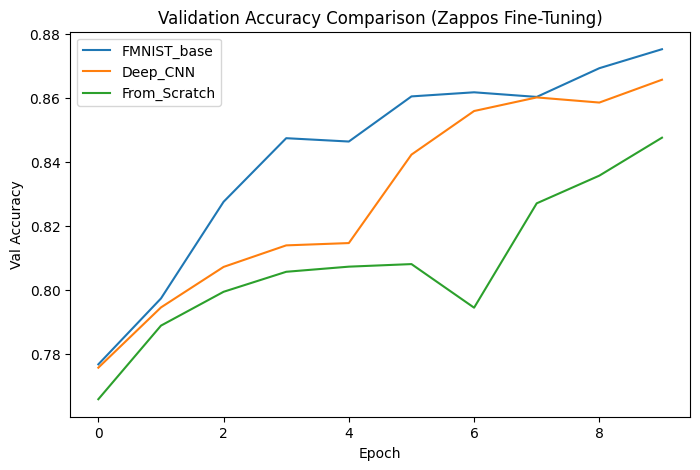

In [ ]:
plt.figure(figsize=(8,5))
for name, hist in histories.items():
    plt.plot(hist.history["val_accuracy"], label=f"{name}")
plt.title("Validation Accuracy Comparison (Zappos Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [ ]:
# Load Best Model for Evaluation
final_model = build_zappos_subnet(num_classes)
final_model.load_weights(f"/content/{best_model}_zappos_finetuned.weights.h5")

In [ ]:
# Predict
val_gen.reset()
y_pred_probs = final_model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step


<Figure size 600x600 with 0 Axes>

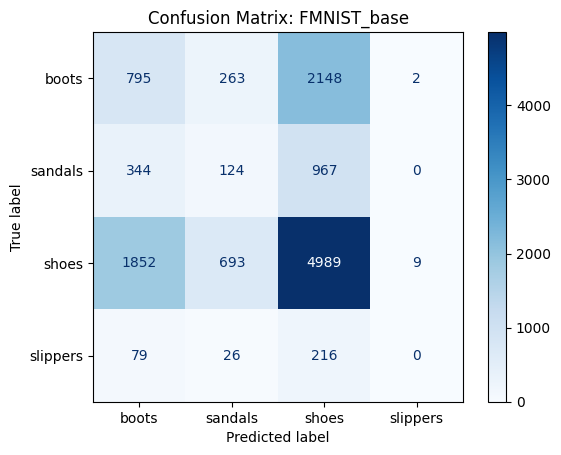

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

labels_list = list(train_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_list)
plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix: {best_model}")
plt.show()

In [ ]:
# Classification Report
print(f"\n Classification Report for {best_model}:\n")
print(classification_report(y_true, y_pred, target_names=labels_list))


 Classification Report for FMNIST_base:

              precision    recall  f1-score   support

       boots       0.26      0.25      0.25      3208
     sandals       0.11      0.09      0.10      1435
       shoes       0.60      0.66      0.63      7543
    slippers       0.00      0.00      0.00       321

    accuracy                           0.47     12507
   macro avg       0.24      0.25      0.24     12507
weighted avg       0.44      0.47      0.46     12507



2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step 


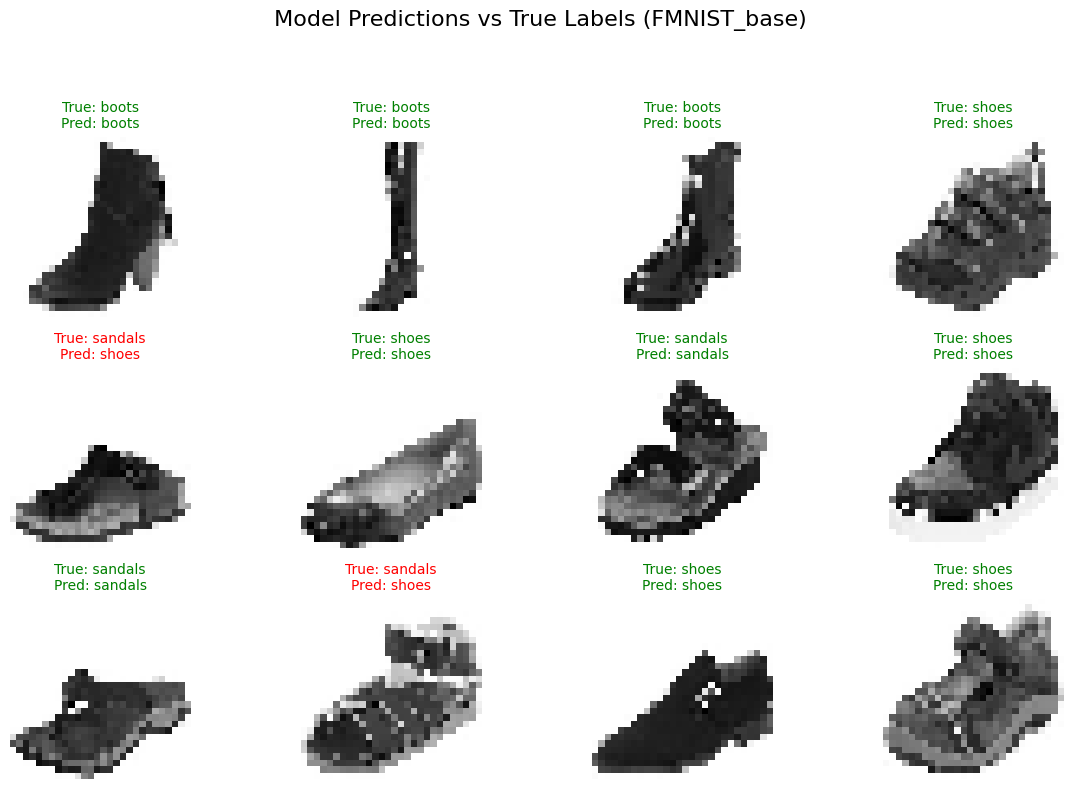

In [ ]:
# Get a batch from validation generator
val_gen.reset()
x_batch, y_true_batch = next(val_gen)

# Predict on this batch
y_pred_probs = final_model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs, axis=1)

# --- Label names ---
label_names = list(val_gen.class_indices.keys())

# --- Display first 12 predictions ---
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_batch[i].squeeze(), cmap="gray")

    true_label = label_names[int(y_true_batch[i])]
    pred_label = label_names[int(y_pred_batch[i])]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
    plt.axis("off")

plt.suptitle(f" Model Predictions vs True Labels ({best_model})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()